# Train the learned-tau predictor with **no actions**, test out-of-distribution

Here the policy takes **no actions** (the stimulus evolves on its own), so the
model is a pure next-step predictor of each task. It is trained on normal
(in-distribution) trials and then evaluated on both a normal trial and an
**out-of-distribution test** trial where the task's dynamics change partway
through (see `tasks/demo_task_tests.ipynb`):

- **drift** — direction reverses at the midpoint
- **binary noise** — Bernoulli probability jumps at the midpoint
- **gaussian process** — spatial/temporal frequency doubles at the midpoint
- **bifurcate** — the bifurcation goes all-0/all-1 instead of half/half

The model uses the learned per-unit timeconstant (`LearnedTauStackedRNNPredictor`).


## Config

In [8]:
# --- task choice ---
TASK = 'bifurcate'   # 'binary_noise' | 'drift' | 'gaussian_process' | 'bifurcate'

# --- task / data ---
VECTOR_LENGTH = 12
SEQ_LEN       = 80
NUM_TRAIN_SEQ = 256
SEED          = 0

# --- model ---
HIDDEN_DIMS = [64, 64, 64]
INITIALIZER_HIDDEN_SIZES = [64, 64]
NOISE_STD   = 0.1
DECODER_SCALE_INPUT  = 2.0
DECODER_SCALE_LATENT = 3.0
TAU_REG_COEFF = 0.05

# --- training ---
NUM_EPOCHS    = 200
BATCH_SIZE    = 64
LEARNING_RATE = 3e-3

In [9]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from tasks import BinaryNoiseTask, DriftTask, GaussianProcessTask, BifurcateTask
from models import LearnedTauStackedRNNPredictor

torch.manual_seed(SEED)


def make_task():
    if TASK == 'binary_noise':
        return BinaryNoiseTask(vector_length=VECTOR_LENGTH, prob=0.3, resample_prob=0.1, test_prob=0.9)
    if TASK == 'drift':
        return DriftTask(vector_length=VECTOR_LENGTH, prob=0.3)
    if TASK == 'gaussian_process':
        return GaussianProcessTask(vector_length=VECTOR_LENGTH,
                                   spatial_temperature=3.0, temporal_temperature=5.0)
    if TASK == 'bifurcate':
        return BifurcateTask(vector_length=VECTOR_LENGTH)
    raise ValueError(f'unknown TASK: {TASK}')

## Build training data (no actions)

Each training example is a plain (in-distribution) rollout of the task.

In [10]:
train_stim = np.stack([make_task().generate(SEQ_LEN, seed=1000 + i) for i in range(NUM_TRAIN_SEQ)])
train_x = torch.tensor(train_stim, dtype=torch.float32)
print('train_x', tuple(train_x.shape))

train_x (256, 80, 12)


## Build and train the model (action_dim = 0)

In [11]:
decoder_scale = [DECODER_SCALE_INPUT] + [DECODER_SCALE_LATENT] * (len(HIDDEN_DIMS) - 1)
model = LearnedTauStackedRNNPredictor(
    input_dim=VECTOR_LENGTH, hidden_dims=HIDDEN_DIMS, action_dim=0,
    initializer_hidden_sizes=INITIALIZER_HIDDEN_SIZES, noise_std=NOISE_STD,
    decoder_scale=decoder_scale, tau_reg_coeff=TAU_REG_COEFF)
NUM_LAYERS = model.num_layers

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
l1_hist = [[] for _ in range(NUM_LAYERS)]
model.train()
for epoch in range(NUM_EPOCHS):
    perm = torch.randperm(train_x.shape[0])
    ep_l1 = np.zeros(NUM_LAYERS)
    nb = 0
    for start in range(0, train_x.shape[0], BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]
        optimizer.zero_grad()
        res = model.compute_losses(train_x[idx])
        res['total'].backward()
        optimizer.step()
        ep_l1 += np.array([t.item() for t in res['l1']])
        nb += 1
    ep_l1 /= nb
    for i in range(NUM_LAYERS):
        l1_hist[i].append(ep_l1[i])
    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f'epoch {epoch + 1:4d}  ' + '  '.join(f'L{i}={ep_l1[i]:.4f}' for i in range(NUM_LAYERS)))
print('mean tau per layer:', [round(float(t.mean()), 3) for t in model.compute_losses(train_x[:8])['taus']])

epoch    1  L0=0.4766  L1=0.2205  L2=0.1602
epoch   50  L0=0.0539  L1=0.0321  L2=0.0106
epoch  100  L0=0.0367  L1=0.0267  L2=0.0068
epoch  150  L0=0.0324  L1=0.0240  L2=0.0049
epoch  200  L0=0.0282  L1=0.0240  L2=0.0052
mean tau per layer: [0.204, 0.004, 0.023]


## Evaluate on a training trial and an out-of-distribution test trial

The same seed is used for both, so the first half is identical; only the second
half differs (after the dashed switch line). We plot layer 0's next-step
prediction and the learned tau for each.


In [12]:
def plot_panels(panels, switch_step=None, panel_height=2.3):
    n = len(panels); T = panels[0]['data'].shape[0]
    fig = plt.figure(figsize=(9, 0.5 + panel_height * n))
    gs = fig.add_gridspec(n, 2, width_ratios=[40, 1], hspace=0.5, wspace=0.04)
    axes = []
    for k, p in enumerate(panels):
        ax = fig.add_subplot(gs[k, 0], sharex=axes[0] if axes else None)
        im = ax.imshow(p['data'].T, aspect='auto', cmap=p['cmap'],
                       vmin=p.get('vmin'), vmax=p.get('vmax'), interpolation='nearest')
        ax.set_title(p['title']); ax.set_ylabel(p.get('ylabel', 'element'))
        if switch_step is not None:
            ax.axvline(switch_step - 0.5, color='w', lw=1.5, ls='--')
            ax.axvline(switch_step - 0.5, color='k', lw=0.6, ls='--')
        fig.colorbar(im, cax=fig.add_subplot(gs[k, 1]))
        axes.append(ax)
    for ax in axes[:-1]:
        plt.setp(ax.get_xticklabels(), visible=False)
    axes[-1].set_xlabel('timestep')
    plt.show()


def eval_and_plot(stim, title, switch_step=None):
    x = torch.tensor(stim, dtype=torch.float32)[None]
    model.eval()
    with torch.no_grad():
        out = model(x)
    gt   = out['inputs'][0][0].numpy()[1:]        # input[t+1]
    pred = out['predictions'][0][0].numpy()[:-1]  # aligned prediction
    tau0 = out['taus'][0][0].numpy()[:-1]         # layer-0 per-unit tau, aligned
    err  = np.abs(pred - gt)
    print(f'{title}: mean L1 = {err.mean():.4f}  '
          f'(first half {err[:len(err)//2].mean():.4f}, second half {err[len(err)//2:].mean():.4f})')
    plot_panels([
        {'title': f'{title}: ground truth (input[t+1])', 'data': gt, 'cmap': 'viridis', 'vmin': 0, 'vmax': 1},
        {'title': 'layer-0 prediction', 'data': pred, 'cmap': 'viridis', 'vmin': 0, 'vmax': 1},
        {'title': 'absolute error', 'data': err, 'cmap': 'magma'},
        {'title': 'layer-0 tau (per unit)', 'data': tau0, 'cmap': 'cividis', 'vmin': 0, 'vmax': 1, 'ylabel': 'hidden unit'},
    ], switch_step=switch_step)


eval_train = make_task().generate(SEQ_LEN, seed=9000)             # in-distribution
eval_test  = make_task().generate(SEQ_LEN, seed=9000, test=True)  # OOD test
switch_col = SEQ_LEN // 2 - 1  # midpoint after the input[t+1] alignment

### In-distribution (training) trial

training trial: mean L1 = 0.0262  (first half 0.0259, second half 0.0265)


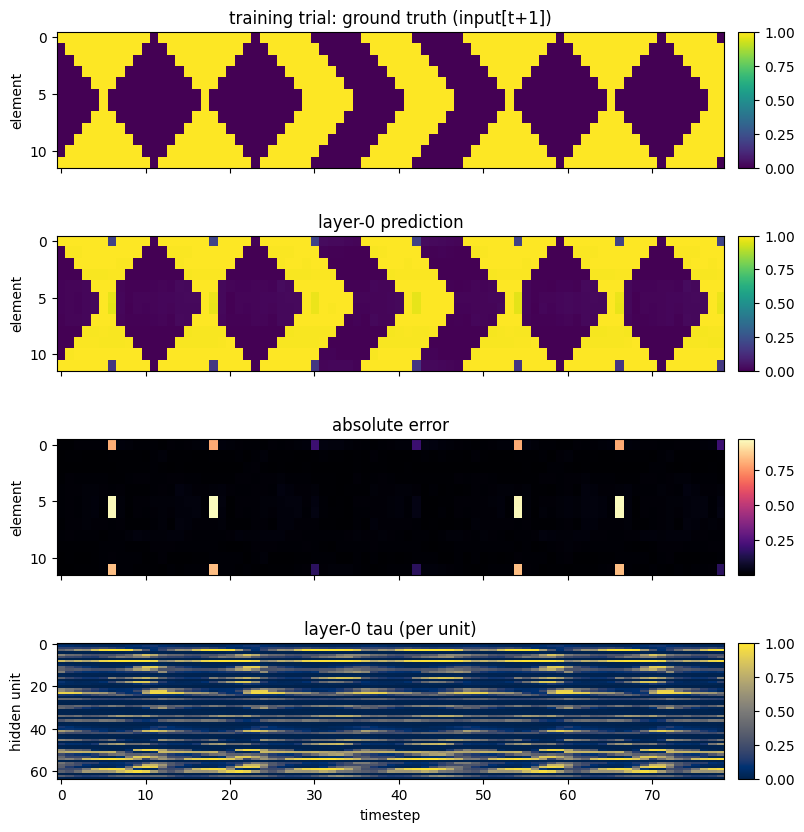

In [13]:
eval_and_plot(eval_train, 'training trial', switch_step=None)

### Out-of-distribution test trial

The dynamics change at the dashed line; watch the prediction error after it.

test trial (OOD): mean L1 = 0.1115  (first half 0.0259, second half 0.1950)


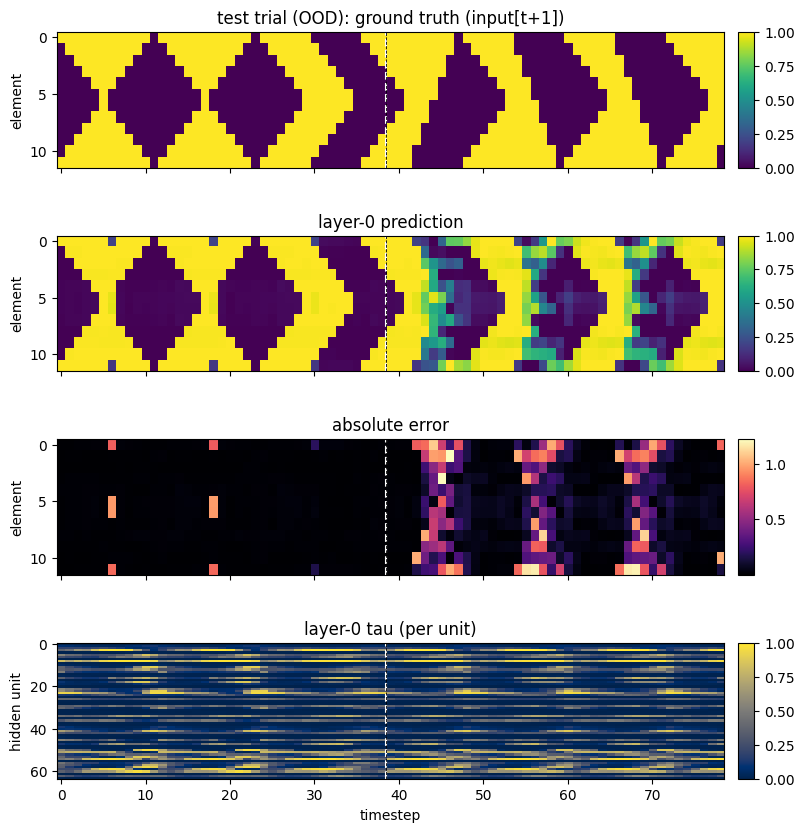

In [14]:
eval_and_plot(eval_test, 'test trial (OOD)', switch_step=switch_col)